# Hồi quy tuyến tính (Linear Regression)

Cài đặt mô hình hồi quy tuyến tính với thư viện PyTorch

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
rng = np.random

In [2]:
# Parameters.
learning_rate = 0.01 # Toc do hoc, kieu nhu kich thuoc 1 buoc chan mo hinh se buoc
training_steps = 1000 # Tong so lan mo hinh thuc hien vong lap: du doan -> tinh sai so -> cap nhat trong so
display_step = 50 # Cu sau 50 buoc, in ra ket qua du doan va sai so

In [3]:
# Xây dựng dữ liệu
X = np.array([3.3,4.4,5.5,6.71,6.93,4.168,9.779,6.182,7.59,2.167,
              7.042,10.791,5.313,7.997,5.654,9.27,3.1])
Y = np.array([1.7,2.76,2.09,3.19,1.694,1.573,3.366,2.596,2.53,1.221,
              2.827,3.465,1.65,2.904,2.42,2.94,1.3])

In [4]:
inputs = torch.from_numpy(X)
targets = torch.from_numpy(Y)

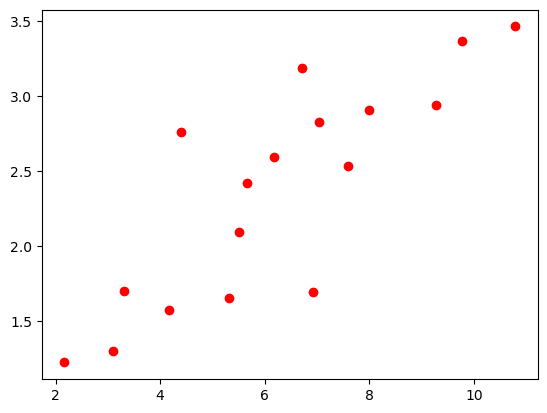

In [5]:
# Trực quan hóa dữ liệu
plt.plot(X, Y, 'ro', label='Original data')
plt.show()

In [6]:
# Xây dựng hàm hồi quy (Wx + b).
def model(x):
    return x * w + b

In [7]:
# Khởi tạo giá trị trọng số W và bias
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

In [8]:
# Xây dựng hàm mất mát (loss function)
# Đọc thêm về reduce_mean tại: https://docs.w3cub.com/tensorflow~python/tf/reduce_mean

# MSE loss
def mse(t1, t2):
    diff = t1 - t2
    return torch.sum(diff * diff) / diff.numel()

In [9]:
preds = model(inputs)
preds

tensor([-0.5495, -0.8751, -1.2007, -1.5589, -1.6241, -0.8064, -2.4674, -1.4026,
        -1.8194, -0.2141, -1.6572, -2.7670, -1.1454, -1.9399, -1.2463, -2.3168,
        -0.4903], dtype=torch.float64, grad_fn=<AddBackward0>)

In [10]:
# in giá trị loss khi chưa xảy ra quá trình học
loss = mse(preds, targets)
print(loss)

tensor(16.1074, dtype=torch.float64, grad_fn=<DivBackward0>)


In [11]:
# Compute gradients
loss.backward()

In [12]:
# thay đổi giá trị weights và reset lại gradient
with torch.no_grad():
    w -= w.grad * learning_rate
    b -= b.grad * learning_rate
    w.grad.zero_()
    b.grad.zero_()

In [13]:
# in giá trị loss sau khi xảy ra quá trình học (cập nhật trọng số)
preds = model(inputs)
loss = mse(preds, targets)
print(loss)

tensor(0.3134, dtype=torch.float64, grad_fn=<DivBackward0>)


In [17]:
# Huấn luyện mô hình với training_steps đã được xác định từ trước
losses = []
for i in range(training_steps):
    preds = model(inputs)
    loss = mse(preds, targets)
    losses.append(loss.item())
    loss.backward()
    with torch.no_grad():
        w -= w.grad * learning_rate
        b -= b.grad * learning_rate
        w.grad.zero_()
        b.grad.zero_()

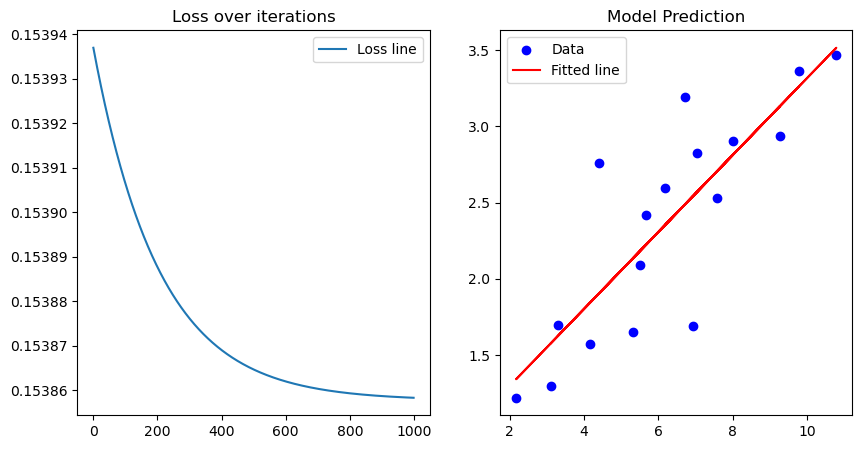

In [ ]:
# Chuyen losses tu tensor sang dang float de ve bieu do
# Dung .item()
losses_float = [l.item() if torch.is_tensor(l) else l for l in losses]

# Tinh toan y_pred sau khi da hoc xong, de ve duong du doan (fitted line)
with torch.no_grad():
    y_pred = (w * X + b)
    y_pred_np = y_pred.detach().cpu().numpy()

# Chuyen sang numpy de ve bieu do
X_np = X.detach().cpu().numpy() if torch.is_tensor(X) else X

# 4. Vẽ biểu đồ
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(range(len(losses_float)), losses_float, label='Loss line')
plt.title("Loss over iterations")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_np, targets.detach().cpu().numpy() if torch.is_tensor(targets) else targets, color='blue', label='Data')
plt.plot(X_np, y_pred_np, color='red', label='Fitted line')
plt.title("Model Prediction")
plt.legend()

plt.show()

In [23]:
import matplotlib.pyplot as plt

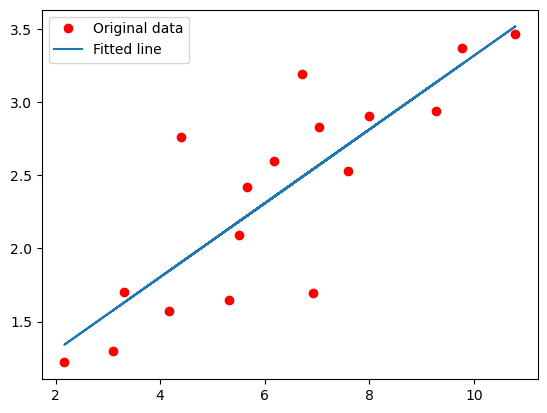

In [ ]:
# Mô hình hóa sự tương quan giữa những điểm dữ liệu và phương trình tuyến tính
plt.plot(X, Y, 'ro', label='Original data')
plt.plot(X, (w * inputs + b).detach().numpy(), label='Fitted line')
plt.legend()
plt.show()